# Machine Learning in Python - Project 

Due Friday, Apr 10th by 4 pm.

*Jingyi Chen, Zixuan Deng, Xuefei Sun*

## Setup

*Install any packages here, define any functions if neeed, and load data*

In [1]:
# Add any additional libraries or submodules below

# Data libraries
import pandas as pd
import numpy as np

# Plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn modules
import sklearn
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

In [2]:
# Load data  
df = pd.read_csv("unicef_malawi.csv")
df.head()

,HH1,HH2,LN,FS4,CB3,CB4,CB5A,CB5B,CB7,CB11,...,HC19,TN1,WS1,WS3,WS4,WS7,WS11,WS14,WS15,HW5
0,1.0,2.0,2.0,2.0,14.0,YES,PRIMARY,CLASS/GRADE 6,YES,NO,...,NO,NO,PIPED WATER: PUBLIC TAP / STANDPIPE,ELSEWHERE,5.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,ELSEWHERE,YES,NO
1,1.0,3.0,1.0,1.0,5.0,YES,ECE,NaN,YES,NO,...,NO,YES,TUBE WELL / BOREHOLE,ELSEWHERE,30.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITHOUT SLAB / OPEN PIT,IN OWN YARD / PLOT,NO,YES
2,1.0,4.0,2.0,2.0,16.0,YES,PRIMARY,CLASS/GRADE 7,YES,NO,...,NO,YES,TUBE WELL / BOREHOLE,ELSEWHERE,6.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,NO,YES
3,1.0,8.0,2.0,2.0,13.0,YES,PRIMARY,CLASS/GRADE 7,YES,NO,...,NO,YES,TUBE WELL / BOREHOLE,ELSEWHERE,30.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,NO,NO
4,1.0,10.0,2.0,2.0,14.0,YES,PRIMARY,CLASS/GRADE 6,YES,NO,...,NO,YES,TUBE WELL / BOREHOLE,ELSEWHERE,8.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,NO,NO


# Introduction

This dataset is from the UNICEF Malawi Survey and contains information on children's demographics, education, family conditions and well-being.  

*Briefly outline the approaches being used and the conclusions that you are able to draw.*

# Exploratory Data Analysis and Feature Engineering
The data used in this study is sourced from the UNICEF Malawi Survey, aiming to predict an children's tendencies towards depression through multiple indicators such as family environment and personal education.  

*1. Data Discussion*  

Filter out the necessary variables from unicef_malawi.csv as follows:  

Family background:  
Wealth Score (wscore): This is a comprehensive index that reflects the possession of family assets (such as housing materials, durable consumer goods). In resource-scarce regions, a low wealth score is usually positively correlated with higher survival anxiety.  
Sanitation Facilities and water Resources (WS4, WS15, WS7): The duration of water collection reflects the degree of infrastructure improvement and the burden of household labor. Shared toilets (WS15) and insufficient drinking water (WS7) not only affect physical health, but also are important sources of a sense of dignity in life and psychological stress.  
Health Protection (TN1): The number of mosquito nets is a proxy indicator of malaria prevention capacity. In areas with a high incidence of malaria, the lack of health security will significantly increase the psychological burden on family members.  

Violent tendencies:  
Mother's Attitude towards domestic Violence (DV1A-E): It includes five detailed scenario descriptions of "under what circumstances a husband can hit his wife". If respondents choose "YES" in multiple scenarios, it reflects their internalization and tolerance of violent behavior, and perhaps they will pass on this suppressed pressure to their children.  
Tendency towards corporal punishment of children (FCD2A-K & FCD5): It records various forms of punishment that parents have adopted against their children in the past month (ranging from verbal humiliation to severe corporal punishment). Frequent corporal punishment not only reflects the loss of control of parents' emotional management, but also is a manifestation that can cause depression in children.  

Educational level and social attributes:  
Educational attainment (CB5A & CB7, WB6A): It distinguishes the highest academic qualifications of children and mothers. Individuals with lower educational levels often lack effective coping mechanisms when facing life's challenges and have fewer job opportunities, thus being more prone to depression.  
Marriage and family structure (MSTATUS, MA3, CSURV): Marital status (whether married, whether in a polygamous family) may affect a mother's psychology and thus be reflected in her children.  
The number of children (CSURV) reflects the burden of raising children. Under conditions of limited resources, having too many children may lead to significant economic and psychological stress.  
Mother's satisfaction with life (LS1) : If the mother is dissatisfied with her current life, it indicates that the family is under great pressure and it may affect the child.  

Children's labor time:  
Children's labor indicators (CL2, CL3, CL12, CL13): Record the time children spend on household chores or paid labor. When families are forced to rely on children's labor to make a living, it is usually accompanied by deep anxiety and depression risks for the children.  

Although variables related to fathers were initially considered, they were excluded due to the large amount of missing data. The Male Questionnaire only included a portion of men, resulting in a coverage rate of less than 2% in our dataset. Including these variables will significantly reduce the sample size and introduce selection bias. Therefore, we focus on children, mothers and family characteristics.


The target variable of this study is depression, which was constructed from the questionnaire survey question FCF26.


In [3]:
main= pd.read_csv('unicef_malawi.csv')
#Selected needed variables
selected_from_main = [
    'HH1', 'HH2', 'LN', #Basic links          
    'CB3', #Children ages
    'CB7', #Still at school or not
    'CB5A', #Education level (children)
    'CL2', 'CL3', 'CL12', 'CL13', #Child Labour
    'FCD2A', 'FCD2B', 'FCD2C', 'FCD2D', 'FCD2E', 'FCD2F', 'FCD2G', 'FCD2H', 'FCD2I', 'FCD2J', 'FCD2K', 
    'FCD5', #Physical punishment
    'FCF26', #Depression
    'wscore', #Comprehensive wealth score
    'TN1', #Number of moaquito nets
    'WS4', #Time of fectching water
    'WS7', #Insufficient drinking water
    'WS15', #Share toilet with others
    'WB6A', #Education level
    'LS1', #Life satisfaction
    'DV1A', 'DV1B', 'DV1C', 'DV1D', 'DV1E', #Attutude towards domestic violence
    'MA3', #Husband has another wife or not
    'MSTATUS', #Marrige
    'CSURV' #Number of children
]
existing = [col for col in selected_from_main if col in main.columns]
main = main[existing].copy()
print(main.columns.tolist())
main.info()
main.describe()

['HH1', 'HH2', 'LN', 'CB3', 'CB7', 'CB5A', 'CL2', 'CL3', 'CL12', 'CL13', 'FCD2A', 'FCD2B', 'FCD2C', 'FCD2D', 'FCD2E', 'FCD2F', 'FCD2G', 'FCD2H', 'FCD2I', 'FCD2J', 'FCD2K', 'FCD5', 'FCF26', 'wscore', 'TN1', 'WS4', 'WS7', 'WS15', 'WB6A', 'LS1', 'DV1A', 'DV1B', 'DV1C', 'DV1D', 'DV1E', 'MA3', 'MSTATUS', 'CSURV']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13162 entries, 0 to 13161
Data columns (total 38 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   HH1      13162 non-null  float64
 1   HH2      13162 non-null  float64
 2   LN       13162 non-null  float64
 3   CB3      13059 non-null  float64
 4   CB7      12203 non-null  object 
 5   CB5A     12203 non-null  object 
 6   CL2      13162 non-null  bool   
 7   CL3      4159 non-null   float64
 8   CL12     13162 non-null  bool   
 9   CL13     11092 non-null  object 
 10  FCD2A    11264 non-null  object 
 11  FCD2B    11264 non-null  object 
 12  FCD2C    11264 non-null  object 
 13  FCD2D 

,HH1,HH2,LN,CB3,CL3,wscore,CSURV
count,13162.000000,13162.000000,13162.000000,13059.000000,4159.000000,13162.000000,13162.000000
mean,552.937623,12.708327,1.751633,9.853817,4.318586,0.027097,3.746999
std,320.588443,7.278076,0.565388,3.588369,7.204110,0.990625,1.804803
min,1.000000,1.000000,1.000000,5.000000,0.000000,-1.302800,0.000000
25%,273.000000,7.000000,1.000000,7.000000,1.000000,-0.632998,2.000000
50%,554.000000,13.000000,2.000000,9.000000,2.000000,-0.320947,4.000000
75%,830.000000,19.000000,2.000000,13.000000,5.000000,0.267699,5.000000
max,1112.000000,60.000000,10.000000,17.000000,77.000000,5.337324,12.000000


This dataset contains 13,162 original samples, covering 38 variables. According to the initial examination, the variables are mainly classified into three categories: ID identifiers (such as HH1, HH2, LN), continuous numerical variables (such as family wealth wscore, age CB3), and classification/Boolean variables (such as mother's educational level WB6A, child's labor status CL2).

In [4]:
#Construct binary variable on FCF26
main = main[main['FCF26'].notna()].copy()
main['depression'] = main['FCF26'].apply(
    lambda x: 0 if x == 'NEVER' else 1)
print(main['depression'].value_counts())
print(main['depression'].value_counts(normalize=True))

depression
1    7154
0    5905
Name: count, dtype: int64
depression
1    0.547821
0    0.452179
Name: proportion, dtype: float64


It can be seen that the target variables are relatively balanced, with approximately 55% of the children having some degree of depressive symptoms.

*2. Train/Test Split*  
To prevent data leakage, the dataset is divided into a training set (80%) and a test set (20%) before conducting a detailed exploratory analysis.

In [5]:
from sklearn.model_selection import train_test_split
#Delete original depression column and new 
X = main.drop(columns=['FCF26', 'depression'])
y = main['depression']
#Split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"shape of training set: {X_train.shape}")
print(f"shape of testing set: {X_test.shape}")
print(f"depression proportion of training set: {y_train.mean():.3f}")
print(f"depression proportion of testing set: {y_test.mean():.3f}")
#Delete basic links
id_cols = ['HH1', 'HH2', 'LN']
X_train = X_train.drop(columns=id_cols, errors='ignore')
X_test = X_test.drop(columns=id_cols, errors='ignore')
print("After deleting", X_train.shape[1])

shape of training set: (10447, 37)
shape of testing set: (2612, 37)
depression proportion of training set: 0.548
depression proportion of testing set: 0.548
After deleting 34


*3. Missing Data*  
Before establishing a predictive model, it is first necessary to evaluate the integrity of the feature matrix. We calculated the missing ratio of each feature in the training set and extracted the top 15 variables with the highest missing rates for visualization.

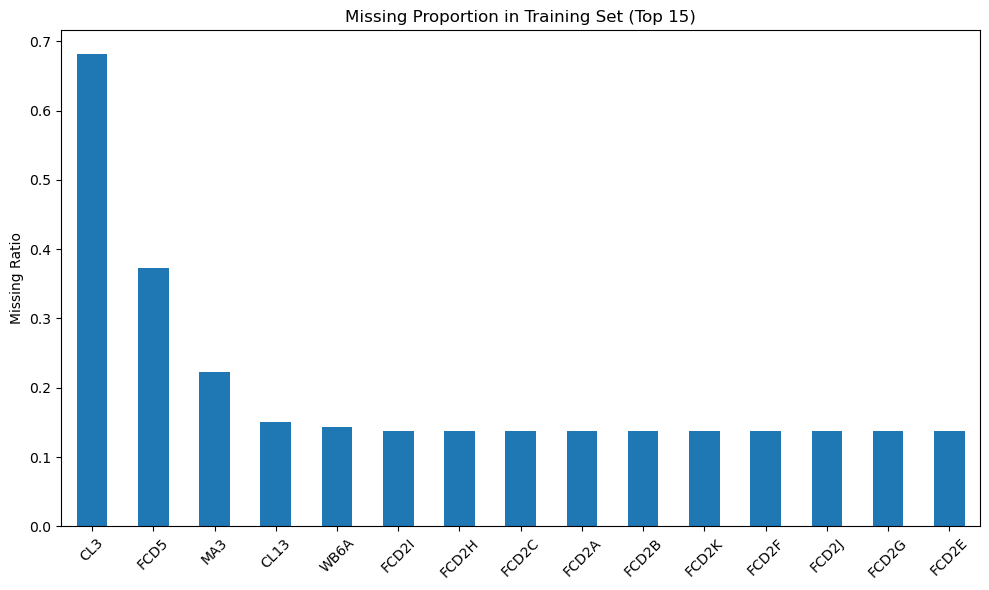

In [6]:
missing_ratio = X_train.isnull().mean().sort_values(ascending=False)
missing_ratio = missing_ratio[missing_ratio > 0]
plt.figure(figsize=(10,6))
missing_ratio.head(15).plot(kind='bar')
plt.title('Missing Proportion in Training Set (Top 15)')
plt.ylabel('Missing Ratio')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

As can be seen from the above figure, the missing rate of CL3 is approximately 68%, which is a relatively large proportion. Consider generating a new CL3\_missing value during preprocess. Because in the context of the questionnaire, the absence of this variable is usually not random but indicates that the family has no children participating in labor. Therefore, by introducing this binary feature, the subsequent model can not only learn the impact of labor intensity on depression through the media-filled CL3, but also capture the mental health differences among children without labor records through CL3\_missing. The remaining missing numerical variables are filled with the median, and the categorical variables are filled with the mode, and these are implemented in the Pipeline.

*4. Distribution of numerical data*  
This section mainly conducts statistical distribution analysis on numerical characteristics, with a focus on three core continuous variables: the age of the interviewed children (CB3), the number of surviving children in the family (CSURV), and the comprehensive wealth score (wscore).


Summary statistics for CB3:
count    10447.000000
mean         9.861013
std          3.595450
min          5.000000
25%          7.000000
50%          9.000000
75%         13.000000
max         17.000000
Name: CB3, dtype: float64


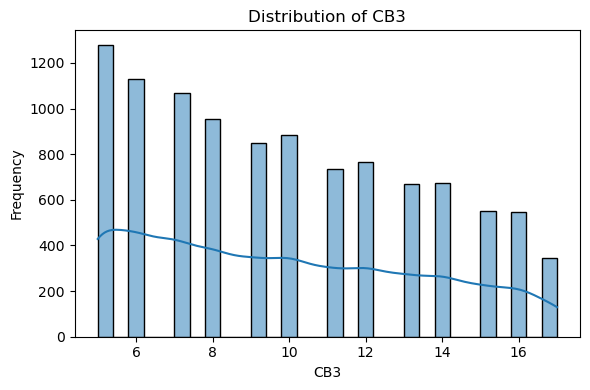


Summary statistics for CSURV:
count    10447.000000
mean         3.758304
std          1.810808
min          0.000000
25%          2.000000
50%          4.000000
75%          5.000000
max         12.000000
Name: CSURV, dtype: float64


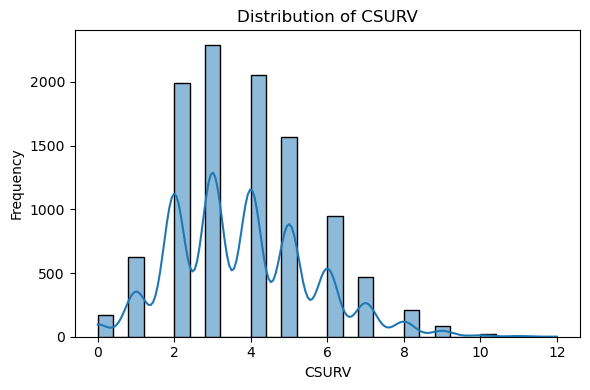


Summary statistics for wscore:
count    10447.000000
mean         0.029275
std          0.994478
min         -1.302800
25%         -0.633861
50%         -0.324383
75%          0.280942
max          5.337324
Name: wscore, dtype: float64


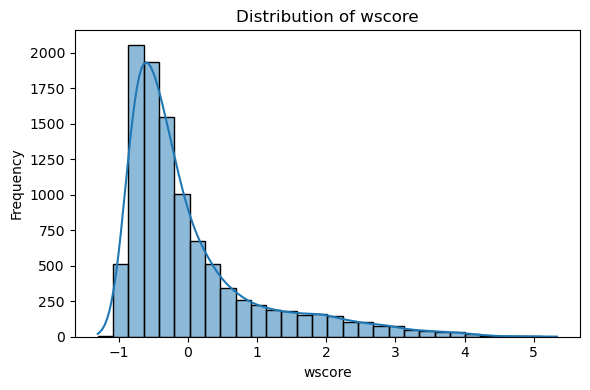

In [7]:
#Select numeric features
num_features = ['CB3', 'CSURV', 'wscore']

for col in num_features:
    if col in X_train.columns:
        #Print summary statistics
        print(f"\nSummary statistics for {col}:")
        print(X_train[col].describe())       
        #Plot histogram
        plt.figure(figsize=(6,4))
        sns.histplot(X_train[col], bins=30, kde=True)
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Frequency')
        plt.tight_layout()
        plt.show()

From the above statistical description and histogram chart, it can be seen that CB3 is generally distributed between the ages of 5 and 17, which is relatively uniform. CRUSV, on the other hand, indicates the relatively high fertility rate in the local area, with people generally choosing to have 2 to 4 children. The wscore shows an overall right-skewed phenomenon, indicating that the wealth situation of local families is not optimistic and there is a significant gap between the rich and the poor, suggesting that these variables need to be appropriately scaled

*5. Relationship between other features and depression*  

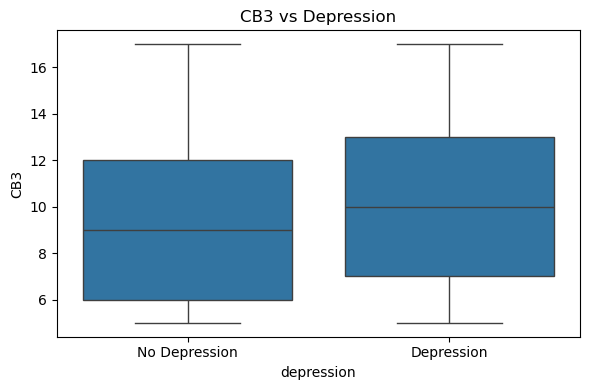

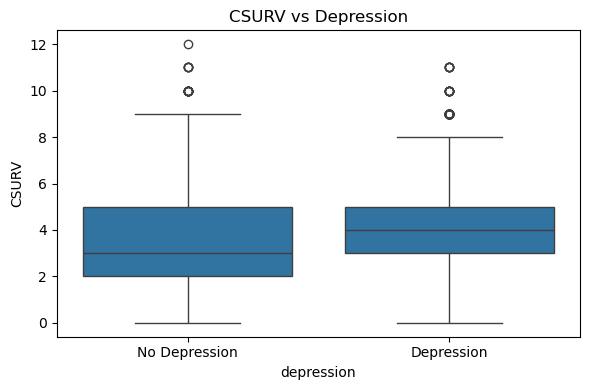

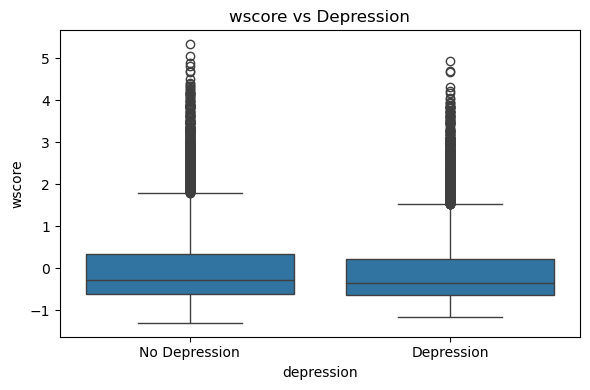

In [8]:
num_features = ['CB3', 'CSURV', 'wscore']
for col in num_features:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=y_train, y=X_train[col])
    plt.xticks([0,1], ['No Depression', 'Depression'])
    plt.title(f'{col} vs Depression')
    plt.tight_layout()
    plt.show()

From the above boxplot, it can be concluded that in terms of CB3, the older the child, the more likely they are to have a tendency towards depression. This might be due to the increased family and labor burdens that teenagers face after entering adolescence. CRUSV shows that the more children a family has, the more prone it is to depression. This might be due to the excessive family burden, requiring older children to do labor, which causes psychological pressure on the children. wscore indicates that the poorer the family, the more likely children are to develop depressive thoughts. This might be due to the fact that a poor family requires more labor, or that both parents are engaged in labor without providing proper guidance and companionship for their children's growth.

*6. Analysis of FCD2 and DV1*  
Calculate the depression rate based on different indicators, then provide a decision on how to dealing with these indicators.

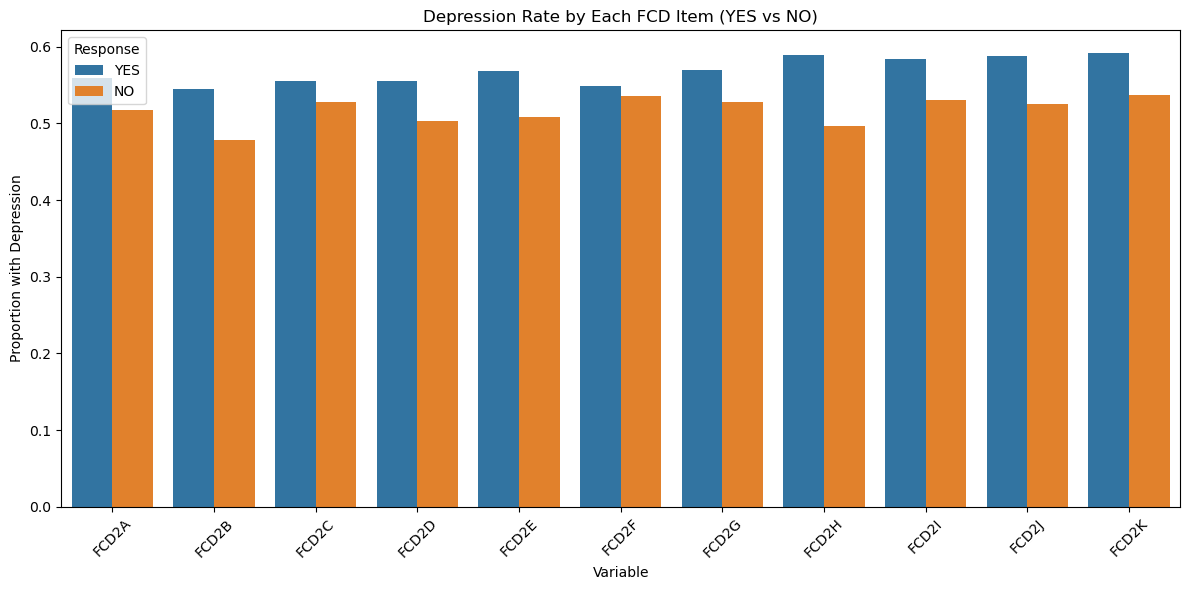

In [10]:
fcd_cols = ['FCD2A', 'FCD2B', 'FCD2C', 'FCD2D', 'FCD2E', 
            'FCD2F', 'FCD2G', 'FCD2H', 'FCD2I', 'FCD2J', 'FCD2K']

#Define a function to calculate the depression rate of each variable in the YES/NO group
def compute_depression_rate_by_response(df, col, y):
    rates = []
    for response in ['YES', 'NO']:
        mask = (df[col] == response)
        if mask.any():
            rate = y[mask].mean()
        else:
            rate = np.nan
        rates.append({'Variable': col, 'Response': response, 'DepressionRate': rate})
    return rates

#Collect all results
all_rates = []
for col in fcd_cols:
    if col in X_train.columns:
        all_rates.extend(compute_depression_rate_by_response(X_train, col, y_train))

df_fcd_rates = pd.DataFrame(all_rates)

#Draw picture
plt.figure(figsize=(12,6))
sns.barplot(data=df_fcd_rates, x='Variable', y='DepressionRate', hue='Response')
plt.xticks(rotation=45)
plt.title('Depression Rate by Each FCD Item (YES vs NO)')
plt.ylabel('Proportion with Depression')
plt.legend(title='Response')
plt.tight_layout()
plt.show()

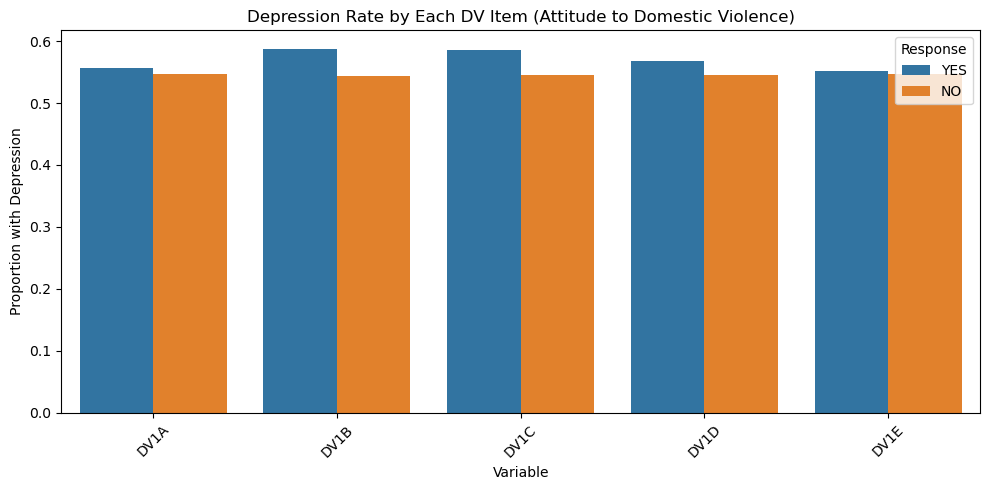

In [11]:
#Same as above
dv_cols = ['DV1A', 'DV1B', 'DV1C', 'DV1D', 'DV1E']
all_rates_dv = []
for col in dv_cols:
    if col in X_train.columns:
        all_rates_dv.extend(compute_depression_rate_by_response(X_train, col, y_train))

df_dv_rates = pd.DataFrame(all_rates_dv)

plt.figure(figsize=(10,5))
sns.barplot(data=df_dv_rates, x='Variable', y='DepressionRate', hue='Response')
plt.xticks(rotation=45)
plt.title('Depression Rate by Each DV Item (Attitude to Domestic Violence)')
plt.ylabel('Proportion with Depression')
plt.legend(title='Response')
plt.tight_layout()
plt.show()

Based on the above two graphs, in terms of views on children's corporal punishment and domestic violence, the group of children who usually answered 'YES' had a higher rate of depression than those who answered 'NO'. In addition, there is often a high correlation between different individual indicators of FCD2 and DV1, which increases the possibility of multicollinearity. Moreover, The situation affecting children's depression may not be one of these indicators. Maybe it is the combined effect of multiple aspects. Therefore, in feature engineering, FCD and DV1 can be summed separately to avoid too many variables affecting the subsequent analysis.

*7. Data Preprocessing and Feature Engineering*  
To ensure that the logistic regression model can converge stably and provide effective predictions, we have designed a multi-stage preprocessing workflow. This process mainly addresses three issues: inconsistent data formats, dimension redundancy, and missing value filling.  

Since the original survey data contains non-numeric symbols, such as 'DK' indicating "don't know", a custom preprocessing function was used to forcibly convert variables like WS4 (water collection time) and CL3 (children's working time) to numeric types, and abnormal inputs were set as missing values (NaN). In addition, the educational attainment (CB5A, WB6A) and life satisfaction (LS1) were standardized and aligned, and the data that did not conform to the grade definition were excluded.  

In order to reduce the complexity of the model and improve the statistical significance of the features, we combined the specific behaviors of corporal punishment (FCD2A-K) into a single continuous variable fcd_sum to quantify the severity of family discipline. Similarly, the attitudes towards domestic violence (DV1A-E) were also aggregated into dv_sum, serving as a proxy variable for the respondents' tolerance for violence.  

We have built a ColumnTransformer pipeline and implemented differentiated strategies for different variable types. Numeric: It uses median imputer and StandardScaler to balance the impact on weights. Ordinal classification: Encode academic qualifications and satisfaction levels using Ordinal encoder to retain their inherent degrees. Nominal classification: One-hot encoding is performed on unordered variables such as marital status. Binary: Directly fill the mode, maintaining its original 0/1 characteristic.


In [16]:
#Preprocessing function
def preprocess_features(X):
    X = X.copy()
    #Ensure CL3 and CL13 are numeric
    if 'CL3' in X.columns:
        X['CL3'] = pd.to_numeric(X['CL3'], errors='coerce')
    if 'CL13' in X.columns:
        X['CL13'] = pd.to_numeric(X['CL13'], errors='coerce')
        X['CL3_missing'] = X['CL3'].isnull().astype(int)
    #Convert WS4 to numeric
    if 'WS4' in X.columns:
        X['WS4'] = pd.to_numeric(X['WS4'], errors='coerce')
    
    #Clean up non-standard values in ordered variables
    cb5a_allowed = ['ECE', 'PRIMARY', 'LOWER SECONDARY', 'UPPER SECONDARY', 'HIGHER']
    if 'CB5A' in X.columns:
        X['CB5A'] = X['CB5A'].where(X['CB5A'].isin(cb5a_allowed), np.nan)
    
    wb6a_allowed = ['PRIMARY', 'LOWER SECONDARY', 'UPPER SECONDARY', 'HIGHER']
    if 'WB6A' in X.columns:
        X['WB6A'] = X['WB6A'].where(X['WB6A'].isin(wb6a_allowed), np.nan)
    
    ls1_allowed = ['VERY UNHAPPY', 'SOMEWHAT UNHAPPY', 'NEITHER HAPPY NOR UNHAPPY', 
                   'SOMEWHAT HAPPY', 'VERY HAPPY']
    if 'LS1' in X.columns:
        X['LS1'] = X['LS1'].where(X['LS1'].isin(ls1_allowed), np.nan)
    
    #Deal with binary variables and bool variables, change into numbers
    binary_map = ['CB7', 'FCD5', 'MA3', 'TN1', 'WS7', 'WS15'] 
    for col in binary_map:
        if col in X.columns:
            if X[col].dtype == 'object':
                X[col] = X[col].map({'YES': 1, 'NO': 0}).fillna(0)
            elif X[col].dtype == 'bool':
                X[col] = X[col].astype(int)
    for col in ['CL2', 'CL12']:
        if col in X.columns:
            X[col] = X[col].astype(int)
    
    #Plus all FCD2A-K together
    fcd_cols = [f'FCD2{chr(ord("A")+i)}' for i in range(11)]
    existing_fcd = [c for c in fcd_cols if c in X.columns]
    if existing_fcd:
        fcd_sum = X[existing_fcd].apply(lambda col: col.map(lambda x: 1 if x == 'YES' else 0)).fillna(0).sum(axis=1)
        X['fcd_sum'] = fcd_sum
        X = X.drop(columns=existing_fcd)
    #Plus all DV1A-E together
    dv_cols = [f'DV1{chr(ord("A")+i)}' for i in range(5)]
    existing_dv = [c for c in dv_cols if c in X.columns]
    if existing_dv:
        dv_sum = X[existing_dv].apply(lambda col: col.map(lambda x: 1 if x == 'YES' else 0)).fillna(0).sum(axis=1)
        X['dv_sum'] = dv_sum
        X = X.drop(columns=existing_dv)
    return X
X_train_processed = preprocess_features(X_train)
X_test_processed = preprocess_features(X_test)
#Confirm all types of the columns
all_cols = X_train_processed.columns.tolist()
numeric_cols = ['CB3', 'CL3', 'CL13', 'CSURV', 'wscore', 'fcd_sum', 'dv_sum', 'WS4', 'CL3_missing']
numeric_cols = [c for c in numeric_cols if c in all_cols]

ordinal_cols = ['CB5A', 'WB6A', 'LS1']
ordinal_cols = [c for c in ordinal_cols if c in all_cols]

nominal_cols = ['MSTATUS']
nominal_cols = [c for c in nominal_cols if c in all_cols]

binary_cols = ['CB7', 'CL2', 'CL12', 'FCD5', 'MA3', 'TN1', 'WS7', 'WS15']
binary_cols = [c for c in binary_cols if c in all_cols]
print("numeric cols:", numeric_cols)
print("ordered cols:", ordinal_cols)
print("nominal cols:", nominal_cols)
print("binary cols:", binary_cols)
#Ordinal Encoding (The scores at different levels should be different)
ordinal_categories = []
if 'CB5A' in ordinal_cols:
    ordinal_categories.append(['ECE', 'PRIMARY', 'LOWER SECONDARY', 'UPPER SECONDARY', 'HIGHER'])
if 'WB6A' in ordinal_cols:
    ordinal_categories.append(['PRIMARY', 'LOWER SECONDARY', 'UPPER SECONDARY', 'HIGHER'])
if 'LS1' in ordinal_cols:
    ordinal_categories.append(['VERY UNHAPPY', 'SOMEWHAT UNHAPPY', 'NEITHER HAPPY NOR UNHAPPY', 
                               'SOMEWHAT HAPPY', 'VERY HAPPY'])



numeric cols: ['CB3', 'CL3', 'CL13', 'CSURV', 'wscore', 'fcd_sum', 'dv_sum', 'WS4', 'CL3_missing']
ordered cols: ['CB5A', 'WB6A', 'LS1']
nominal cols: ['MSTATUS']
binary cols: ['CB7', 'CL2', 'CL12', 'FCD5', 'MA3', 'TN1', 'WS7', 'WS15']


# Model Fitting and Tuning

*In this section you should detail and motivate your choice of model and describe the process used to refine, tune, and fit that model. You are encouraged to explore different models but you should NOT include a detailed narrative or code of all of these attempts. At most this section should very briefly mention the methods explored and why they were rejected - most of your effort should go into describing the final model you are using and your process for tuning and validating it.*

*This section should include the full implementation of your final model, including all necessary validation. As with figures, any included code must also be addressed in the text of the document.*

*You should also include a baseline model of your choice and provide a comparison of your model with the baseline model on the test data. You should briefly describe the baseline model considered.*

*8. Baseline model*

Logistic regression was chosen as the baseline model to predict the occurrence of childhood depression. The main reason for selecting logistic regression is that it has good interpretability, and its regression coefficients can directly reflect the influence direction and relative magnitude of each variable on the risk of depression, which is particularly important for this study to understand the key factors affecting children's mental health. At the same time, as a classic linear classification model, logistic regression also provides a clear performance benchmark for the subsequent introduction of more complex nonlinear models, such as random forest or gradient boosting models, thereby determining whether there are significant nonlinear patterns or variable interaction effects in the data.

During the model implementation process, a complete data preprocessing and modeling pipeline was constructed to ensure the consistency of the training and testing processes and avoid data leakage. For numerical variables, missing values were first filled with the median, and then standardized to transform the variables into a distribution with a mean of 0 and a standard deviation of 1, thereby eliminating the influence of different measurement scales on model training. For categorical variables, ordinal encoding or one-hot encoding was used depending on their types, and the most frequent value was used to fill in missing values.

In addition, considering the possible class imbalance problem between depressed and non-depressed samples in the data, the class_weight='balanced' parameter was introduced in the logistic regression model to automatically adjust the weights of different classes, thereby enhancing the model's ability to identify the minority class and avoiding the model's bias towards majority class prediction.

In [17]:
#Build pipeline
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

ordinal_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')), 
    ('encoder', OrdinalEncoder(categories=ordinal_categories, handle_unknown='use_encoded_value', unknown_value=-1))
])

nominal_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

binary_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_cols),
    ('ord', ordinal_transformer, ordinal_cols),
    ('nom', nominal_transformer, nominal_cols),
    ('bin', binary_transformer, binary_cols)
])

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

#Evaluate
pipeline.fit(X_train_processed, y_train)
y_pred = pipeline.predict(X_test_processed)
y_prob = pipeline.predict_proba(X_test_processed)[:, 1]

print("\nclassification report:\n", classification_report(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))
print("confusion matrix:\n", confusion_matrix(y_test, y_pred))


classification report:
               precision    recall  f1-score   support

           0       0.52      0.57      0.54      1181
           1       0.61      0.56      0.59      1431

    accuracy                           0.57      2612
   macro avg       0.57      0.57      0.56      2612
weighted avg       0.57      0.57      0.57      2612

AUC: 0.5908535506573626
confusion matrix:
 [[676 505]
 [629 802]]


On the test set, the AUC of the logistic regression baseline model was 0.591, indicating that the overall predictive performance of the model was relatively weak. From the perspective of classification metrics, the model's performance on the two classes was relatively balanced. For depressed individuals (class 1), the precision was 0.61 and the recall was 0.56, suggesting that the model had a certain degree of false negative detection when identifying depressed people. Combining the confusion matrix, it can be further found that the number of false negatives (629) was slightly higher than that of false positives (505), indicating that the model was more likely to misclassify some depressed individuals as non-depressed.

*9. Candidate Models*

Based on the baseline model (logistic regression), this study further explored multiple candidate models to assess whether the predictive performance could be enhanced by introducing nonlinear structures. Given that the data mainly consists of socioeconomic and family environment variables, this type of tabular data often contains potential nonlinear relationships and interactions among variables, making it necessary to try more expressive models.

During the selection of candidate models, we mainly considered different types of classification methods, including tree-based ensemble models and other nonlinear methods. The initially considered models included Support Vector Machine (SVM), Random Forest, and Gradient Boosting. However, due to the characteristics of the "low signal-to-noise ratio" tabular data of the Malawi Child Mental Health Questionnaire, SVM and neural networks were not applicable. The computational cost of SVM increased significantly due to the large number of ordered categorical variables in the feature set, but it did not bring any substantial AUC improvement. Neural networks failed to converge due to overfitting the noise in the training set. Therefore, these two models were removed from the candidates.

In contrast, tree-based ensemble methods are more robust in handling complex structured tabular data. Considering that local Malawian children may hide or deviate when answering sensitive questions such as depressive tendencies (the target variable) and experiences of domestic violence, there must be random noise in the data. Random Forest builds hundreds of independent decision trees in parallel through the Bagging mechanism and conducts majority voting. This ensemble approach has extremely strong robustness to noise and can effectively smooth out the fluctuations caused by individual abnormal samples. In addition, it can easily capture the nonlinear threshold truncation effects in continuous variables such as family comprehensive wealth (wscore) and is less prone to overfitting. ； The Gradient Boosting model, by gradually fitting residuals, can learn complex patterns more precisely. In the complex social context of Malawi, the factors leading to childhood depression may be extremely subtle (such as a mild labor burden in a single-parent family). The serial error correction feature of GB enables it to uncover these hidden depression-related factors that are easily overlooked by linear baseline models.
Therefore, this study focuses on selecting Random Forest and Gradient Boosting models as candidate models and compares them with the baseline model. To fairly evaluate the performance of different models, all models are trained under the same data preprocessing pipeline and a 5-fold cross-validation is used for initial screening on the training set, with AUC as the evaluation metric. Ultimately, the model with the best performance based on the cross-validation results is selected for subsequent parameter tuning and evaluation on the test set.


In [18]:
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import cross_val_score

# Define candidate models
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(class_weight='balanced', n_estimators=100, max_depth=10, random_state=42),
    'Gradient Boosting': HistGradientBoostingClassifier(random_state=42)
}

print("Start the 5-Fold cross-validation audition (based on the training set)...\n")
results_auc = {}

# Combine all models into a new pipline
for name, model in models.items():
    clf_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    # Cross validation
    cv_scores = cross_val_score(clf_pipeline, X_train_processed, y_train, cv=5, scoring='roc_auc', n_jobs=-1)
    
    results_auc[name] = cv_scores.mean()
    print(f"[{name}] Average AUC: {cv_scores.mean():.4f} (Standard Deviation: +/- {cv_scores.std():.4f})")

champion = max(results_auc, key=results_auc.get)
print(f"\nThe champion model with the highest initial score is: {champion}")

Start the 5-Fold cross-validation audition (based on the training set)...

[Logistic Regression] Average AUC: 0.5930 (Standard Deviation: +/- 0.0039)
[Random Forest] Average AUC: 0.5953 (Standard Deviation: +/- 0.0054)
[Gradient Boosting] Average AUC: 0.5903 (Standard Deviation: +/- 0.0082)

The champion model with the highest initial score is: Random Forest


After conducting 5-fold cross-validation on the training set, the AUC performance of each candidate model was generally quite similar. The random forest model achieved the highest average AUC (0.5953), which was slightly better than the logistic regression model (0.5930) and the gradient boosting model (0.5903). However, the performance gap between different models was very limited (all within 0.005), indicating that introducing more complex nonlinear models did not bring significant performance improvement. 

It is worth noting that logistic regression, as a linear benchmark model, achieved performance almost equivalent to that of ensemble tree models (random forests and gradient boosting) without the need to model complex nonlinear relationships. This result preliminarily indicates that the key features influencing depression in Malawian children in the data may mainly present an approximately linear relationship structure rather than strongly relying on complex nonlinear or high-order interaction effects. 

From the perspective of model stability, in different cross-validation folds, the standard deviations of AUC for each model are all relatively low (all less than 0.01), indicating that the models perform stably under different data partitions. At the same time, this also indirectly verifies that the partition strategy based on family grouping (GroupShuffleSplit) adopted in the preprocessing stage is reasonable, effectively avoiding the leakage of samples from the same family to the training set and validation set. 

Based on the overall performance and stability, the random forest algorithm ranked first with a slight advantage when using the default parameters. Therefore, in the subsequent analysis, the random forest will be the main candidate model for further hyperparameter tuning.

*10. Hyperparameter Tuning*

During the model optimization phase of this project, a systematic set of hyperparameter tuning strategies was designed based on the structural characteristics and computational cost of the random forest model. This strategy was mainly carried out from three aspects: model complexity control, integration scale optimization, and search method selection. 

Firstly, in terms of controlling model complexity, a set of structural regularization parameters were introduced, including max_depth, min_samples_split, and min_samples_leaf. These parameters are used to limit the growth capacity of each decision tree, thereby preventing the model from overfitting. Specifically, by constraining the maximum depth of the tree and setting the minimum number of samples required for node division and leaf nodes (for example, setting min_samples_leaf to 2, 4, or 8), it is possible to effectively suppress the model's excessive fitting to local noise, making it more inclined to capture statistically significant overall patterns. 

Secondly, in terms of integration scale, by adjusting the parameter n_estimators (with a range of 100 to 500), the impact of different numbers of decision trees on the model performance is evaluated. Increasing the number of base learners can reduce the variance (variance) brought by a single tree through the "collective voting" mechanism, thereby enhancing the stability and robustness of the model's predictions. 

Finally, regarding the hyperparameter search strategy, considering the large parameter space and limited computing resources, this study adopted random search (RandomizedSearchCV) instead of exhaustive grid search (GridSearchCV). Random search can more efficiently explore the parameter space within the given computational budget. In this study, 15 combinations were randomly sampled from the preset parameter distribution, and the model was evaluated using 5-fold cross-validation. At the same time, the optimization metric was set as roc_auc to ensure that the parameter tuning process is consistent with the core evaluation criteria of the imbalanced classification task.

In [21]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

print("Start building the tuning pipeline for the Random Forest...\n")

# Reassemble the Pipeline of Random Forest model
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor), 
    ('classifier', RandomForestClassifier(class_weight='balanced', random_state=42))
])

# Hyperparameter Grid
param_distributions = {
    'classifier__n_estimators': [100, 200, 300, 500],
    'classifier__max_depth': [5, 10, 15, 20, None],
    'classifier__min_samples_split': [2, 5, 10, 20],
    'classifier__min_samples_leaf': [1, 2, 4, 8]
}

# Initialize RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_distributions,
    n_iter=15, 
    cv=5, 
    scoring='roc_auc', 
    random_state=42, 
    n_jobs=-1, 
    verbose=1 
)


print("Start hyperparameter tuning (It may take 1 to 3 minutes)...\n")
random_search.fit(X_train_processed, y_train)

print(f"The best combination of parameters found: {random_search.best_params_}")
print(f"The highest AUC on the validation set: {random_search.best_score_:.4f}\n")

print("==========================================")
print("FINAL EVALUATION")
print("==========================================")

best_model = random_search.best_estimator_

y_test_pred = best_model.predict(X_test_processed)
y_test_prob = best_model.predict_proba(X_test_processed)[:, 1]

final_auc = roc_auc_score(y_test, y_test_prob)
print(f"Final Test AUC: {final_auc:.4f}\n")
print("Classification Report:\n", classification_report(y_test, y_test_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))

Start building the tuning pipeline for the Random Forest...

Start hyperparameter tuning (It may take 1 to 3 minutes)...

Fitting 5 folds for each of 15 candidates, totalling 75 fits
The best combination of parameters found: {'classifier__n_estimators': 300, 'classifier__min_samples_split': 10, 'classifier__min_samples_leaf': 8, 'classifier__max_depth': 15}
The highest AUC on the validation set: 0.5977

FINAL EVALUATION
Final Test AUC: 0.5826

Classification Report:
               precision    recall  f1-score   support

           0       0.52      0.53      0.52      1181
           1       0.61      0.60      0.60      1431

    accuracy                           0.57      2612
   macro avg       0.56      0.56      0.56      2612
weighted avg       0.57      0.57      0.57      2612

Confusion Matrix:
 [[625 556]
 [576 855]]


Although hyperparameter tuning improved the cross-validation AUC to 0.5977, the final test AUC slightly decreased to 0.5826. This discrepancy suggests that the selected hyperparameters may have been mildly overfitted to the validation folds during the search process.

Given the relatively small performance gap (approximately 0.015), this difference is within the expected variance of cross-validation estimates and does not indicate an important issue in the modelling pipeline. Instead, it may lead to the inherent randomness in model selection procedures such as RandomizedSearchCV.

Moreover, the limited overall performance (AUC around 0.58–0.60) suggests that model performance is likely limited by the predictive power of the available features rather than the choice of hyperparameters. This implies that further improvements would more likely come from feature engineering or incorporating additional informative variables, rather than increasing model complexity.

*11. Model Evaluation and Comparison*

After the model construction and parameter tuning were completed, this study conducted the final evaluation and comparison between the logistic regression model and the tuned random forest model on an independent test set. The evaluation metrics include AUC, classification reports (precision, recall, F1-score), and ROC curve, which measure the classification performance of the model from multiple dimensions.

 Random Foreste Model vs. Logestic Model on Test Set)
Logistic Regression
Test AUC: 0.5909
Classification Report:
               precision    recall  f1-score   support

           0       0.52      0.57      0.54      1181
           1       0.61      0.56      0.59      1431

    accuracy                           0.57      2612
   macro avg       0.57      0.57      0.56      2612
weighted avg       0.57      0.57      0.57      2612

--------------------------------------------------
Tuned Random Forest
Test AUC: 0.5826
Classification Report:
               precision    recall  f1-score   support

           0       0.52      0.53      0.52      1181
           1       0.61      0.60      0.60      1431

    accuracy                           0.57      2612
   macro avg       0.56      0.56      0.56      2612
weighted avg       0.57      0.57      0.57      2612

--------------------------------------------------


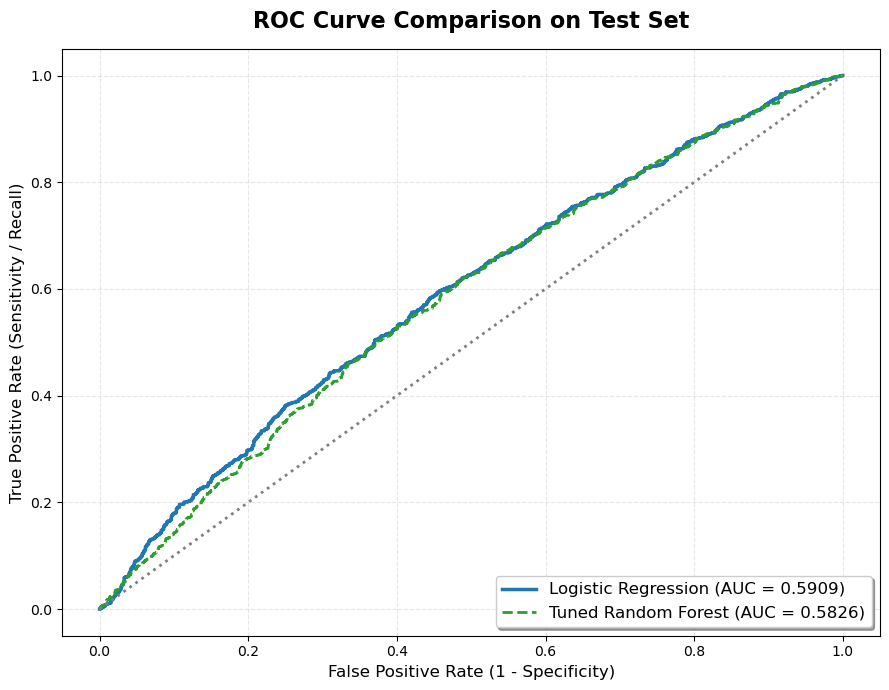

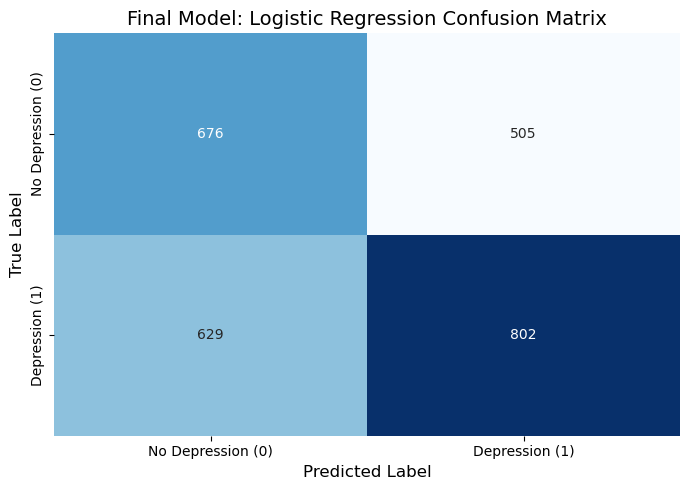

In [29]:
from sklearn.metrics import roc_curve, auc, roc_auc_score, classification_report
from sklearn.linear_model import LogisticRegression

print(" Random Foreste Model vs. Logestic Model on Test Set)")

# Baseline LR model
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])
lr_pipeline.fit(X_train_processed, y_train)

# Predict on the test set
y_test_prob_lr = lr_pipeline.predict_proba(X_test_processed)[:, 1]
y_test_pred_lr = lr_pipeline.predict(X_test_processed)
auc_lr = roc_auc_score(y_test, y_test_prob_lr)

print("Logistic Regression")
print(f"Test AUC: {auc_lr:.4f}")
print("Classification Report:\n", classification_report(y_test, y_test_pred_lr))
print("-" * 50)

# Tuned Random Forest
best_rf_model = random_search.best_estimator_

# Predict on the test set
y_test_prob_rf = best_rf_model.predict_proba(X_test_processed)[:, 1]
y_test_pred_rf = best_rf_model.predict(X_test_processed)
auc_rf = roc_auc_score(y_test, y_test_prob_rf)

print("Tuned Random Forest")
print(f"Test AUC: {auc_rf:.4f}")
print("Classification Report:\n", classification_report(y_test, y_test_pred_rf))
print("-" * 50)


# ROC curves for two-model comparison
plt.figure(figsize=(9, 7))

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_test_prob_lr)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.4f})', color='#1f77b4', linewidth=2.5)

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_test_prob_rf)
plt.plot(fpr_rf, tpr_rf, label=f'Tuned Random Forest (AUC = {auc_rf:.4f})', color='#2ca02c', linestyle='--', linewidth=2)

plt.plot([0, 1], [0, 1], color='gray', linestyle=':', linewidth=2)

plt.title('ROC Curve Comparison on Test Set', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=12)
plt.legend(loc='lower right', fontsize=12, frameon=True, shadow=True)
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()

plt.show()


#Extract the confusion matrix of LR Model
cm_lr = confusion_matrix(y_test, y_test_pred_lr)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Depression (0)', 'Depression (1)'],
            yticklabels=['No Depression (0)', 'Depression (1)'])
plt.title('Final Model: Logistic Regression Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

In the multi-model ROC curve comparison chart (ROC Curve Comparison), the blue solid line representing logistic regression closely follows or even slightly encloses the green dotted line representing the optimized random forest in most threshold intervals. From the final numerical performance, the baseline logistic regression achieved the highest score on the unseen test set (Test AUC = 0.5909), surpassing the random forest obtained through hyperparameter search (Test AUC = 0.5826). 

The classification report and confusion matrix heatmap of logistic regression show that the overall accuracy of the model on the test set is 57%. It is worth noting that thanks to the 'class_weight='balanced'' parameter we introduced at the early stage of model construction, the model effectively overcame the bias caused by sample imbalance. From the classification report, it can be seen that the recall rate of the model for healthy children (Class 0) is 0.57, and for depressed children (Class 1) is 0.56, achieving an excellent balance. This means that the model did not adopt the speculative strategy of "randomly guessing one category", but truly learned the feature distributions of positive and negative samples.

*12. Model Stability Analysis*

In the aforementioned model evaluation, both the random forest and logistic regression models demonstrated relatively limited predictive capabilities (with an AUC of approximately 0.58–0.60), suggesting that there might be high noise or redundant features in the data. To further verify this hypothesis and enhance the robustness and interpretability of the model, this study introduced feature selection and model simplification strategies to conduct a systematic analysis of the feature space.

Firstly, a preliminary compression of features was achieved using the importance-based selection method for tree models (Random Forest + SelectFromModel). Secondly, the logistic regression model with L1 regularization (Lasso) was used to further screen the features. L1 regularization has the characteristic of automatically compressing the coefficients of unimportant features to 0, thereby achieving sparse modeling. On this basis, a simplified logistic regression model (Simplified Logistic Regression) was constructed. After selecting the core features through L1 regularization, the regularization strength parameter C of the model was tuned. This method helps to reduce the model complexity while improving its generalization ability and stability.

dimensionality reduction of tree model：remain 7 core features。
Lasso Regularization：the coefficients of 6 redundant features were compressed to 0, and it was determined to be pure noise.

Conclusion: Both double tests confirm that there is a large amount of noise in the dataset, and a streamlined model must be constructed. 

Construct final terse LR model
Fitting 5 folds for each of 5 candidates, totalling 25 fits


/opt/conda/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/o

The best C parameter: 0.01
Test AUC of Simplified LR: 0.5904

Feature Importance


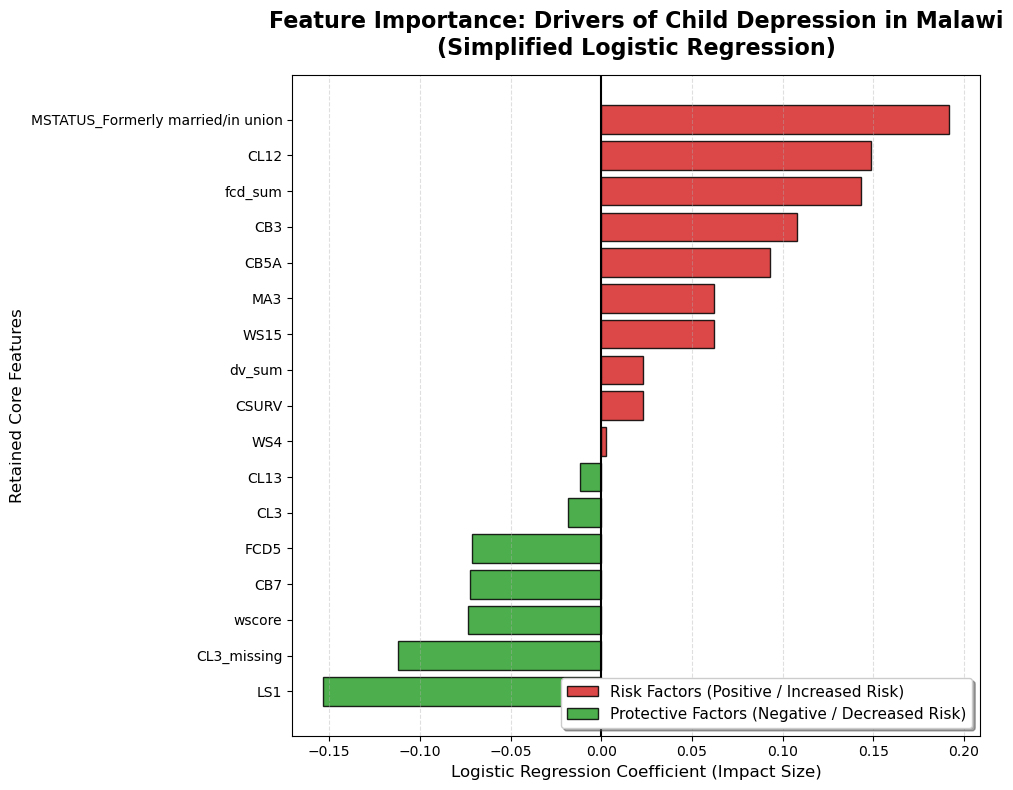

In [37]:
from sklearn.feature_selection import SelectFromModel

#Dimension reduction verification of tree-based model
rf_selector = SelectFromModel(RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'))

rf_fs_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('feature_selection', rf_selector)
])
rf_fs_pipeline.fit(X_train_processed, y_train)
rf_retained = np.sum(rf_fs_pipeline.named_steps['feature_selection'].get_support())
print(f"dimensionality reduction of tree model：remain {rf_retained} core features。")

# Lasso L1 dimension reduction verification
lasso_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(penalty='l1', solver='liblinear', C=0.1, class_weight='balanced', random_state=42))
])
lasso_pipeline.fit(X_train_processed, y_train)
lasso_coefs = lasso_pipeline.named_steps['classifier'].coef_[0]
zero_coef_count = np.sum(lasso_coefs == 0)
print(f"Lasso Regularization：the coefficients of {zero_coef_count} redundant features were compressed to 0, and it was determined to be pure noise.\n")
print("Conclusion: Both double tests confirm that there is a large amount of noise in the dataset, and a streamlined model must be constructed. \n")



print("Construct final terse LR model")

lasso_selector = SelectFromModel(
    LogisticRegression(penalty='l1', solver='liblinear', C=0.1, class_weight='balanced', random_state=42)
)

# classifier
final_lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

# pipeline
final_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('feature_selection', lasso_selector),
    ('classifier', final_lr)
])

# C-parameter (regularization strength) tuning on the final logistic regression
param_grid_lr = {
    'classifier__C': [0.01, 0.1, 1.0, 10.0, 100.0]
}

grid_search_lr = GridSearchCV(
    estimator=final_pipeline,
    param_grid=param_grid_lr,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search_lr.fit(X_train_processed, y_train)
best_final_lr = grid_search_lr.best_estimator_

print(f"The best C parameter: {grid_search_lr.best_params_['classifier__C']}")

# Evaluation on the test set
y_test_prob_final = best_final_lr.predict_proba(X_test_processed)[:, 1]
final_auc_lr = roc_auc_score(y_test, y_test_prob_final)
print(f"Test AUC of Simplified LR: {final_auc_lr:.4f}\n")



print("Feature Importance")

# Original feature name
all_feature_names = best_final_lr.named_steps['preprocessor'].get_feature_names_out()
clean_feature_names = np.array([name.split('__')[-1] for name in all_feature_names])

survivor_mask = best_final_lr.named_steps['feature_selection'].get_support()

# Assign weight coefficient
survivor_names = clean_feature_names[survivor_mask]
final_coefficients = best_final_lr.named_steps['classifier'].coef_[0]

# 4. Combine into DataFrame and ordered
importance_df = pd.DataFrame({
    'Feature': survivor_names,
    'Coefficient': final_coefficients
}).sort_values(by='Coefficient', ascending=True)

#The inducing factor (positive coefficient) is red, and the protective factor (negative coefficient) is green
colors = ['#2ca02c' if val < 0 else '#d62728' for val in importance_df['Coefficient']]

# plot
plt.figure(figsize=(10, 8))
plt.barh(importance_df['Feature'], importance_df['Coefficient'], color=colors, edgecolor='black', alpha=0.85)

plt.title('Feature Importance: Drivers of Child Depression in Malawi\n(Simplified Logistic Regression)', 
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Logistic Regression Coefficient (Impact Size)', fontsize=12)
plt.ylabel('Retained Core Features', fontsize=12)
plt.axvline(x=0, color='black', linestyle='-', linewidth=1.5) # 画一条 0 的基准线
plt.grid(axis='x', linestyle='--', alpha=0.4)

legend_elements = [
    Patch(facecolor='#d62728', edgecolor='black', alpha=0.85, label='Risk Factors (Positive / Increased Risk)'),
    Patch(facecolor='#2ca02c', edgecolor='black', alpha=0.85, label='Protective Factors (Negative / Decreased Risk)')
]
plt.legend(handles=legend_elements, loc='lower right', fontsize=11, frameon=True, shadow=True)

plt.tight_layout()
plt.show()

In the hyperparameter tuning (GridSearchCV) of the simplified logistic regression, the optimal regularization strength is C = 0.01. Here, the C value is the reciprocal of the regularization strength, and a very small C value indicates a strict L2 penalty. It indicates that even though the redundant features that accounted for nearly one-third of the data were already eliminated through Lasso and tree models in the early stage, the algorithm still suppressed the feature weights to prevent overfitting to the noise in the questionnaire data. Secondly, after undergoing feature stripping and regularization suppression, this simplified model still achieved an AUC score of 0.5904 on the independent test set that was not involved in the training. Compared with the initial full-feature baseline model (AUC = 0.5909), the performance degradation was negligible. This confirms that the features that were removed were indeed purely noise with no business value, and the current retained feature matrix has concentrated almost 100% of the effective signals within the dataset.

以下均为测试阶段跑的模型！不计入最终作业！！最后需要删除！！

In [38]:
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score
import time

print("(SVM vs Neural Network)...\n")

# 定义新增的两个模型
extended_models = {
    # 必须加 probability=True 才能算 AUC
    'Support Vector Machine (SVM)': SVC(class_weight='balanced', probability=True, random_state=42),
    
    # MLP 神经网络: 隐藏层设置为 (64, 32)，最大迭代次数设为 500 以确保收敛
    # 注意：MLPClassifier 没有内置的 class_weight 参数，但我们的正负样本比例 55:45 算很平衡了
    'Neural Network (MLP)': MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
}

extended_results_auc = {}

for name, model in extended_models.items():
    print(f"正在训练 {name}，请耐心等待...")
    start_time = time.time()
    
    # 组装 Pipeline (你的 preprocessor 里已经有了 StandardScaler，这对 SVM 和 NN 极其重要！)
    clf_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    # 依然使用 5-Fold 交叉验证保证分数的可靠性
    cv_scores = cross_val_score(clf_pipeline, X_train_processed, y_train, cv=5, scoring='roc_auc', n_jobs=-1)
    
    elapsed_time = time.time() - start_time
    extended_results_auc[name] = cv_scores.mean()
    
    print(f"✅ [{name}] 平均 AUC: {cv_scores.mean():.4f} (耗时: {elapsed_time:.1f} 秒)")
    print("-" * 50)

# 输出扩展海选结果
champion_ext = max(extended_results_auc, key=extended_results_auc.get)
print(f"在高级模型中，得分最高的是: {champion_ext} (AUC: {extended_results_auc[champion_ext]:.4f})")

(SVM vs Neural Network)...

正在训练 Support Vector Machine (SVM)，请耐心等待...
✅ [Support Vector Machine (SVM)] 平均 AUC: 0.5926 (耗时: 118.3 秒)
--------------------------------------------------
正在训练 Neural Network (MLP)，请耐心等待...


/opt/conda/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


✅ [Neural Network (MLP)] 平均 AUC: 0.5467 (耗时: 79.7 秒)
--------------------------------------------------
在高级模型中，得分最高的是: Support Vector Machine (SVM) (AUC: 0.5926)


In [39]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

print("开始构建 Gradient Boosting (梯度提升树) 的终极调优管道...\n")

# 1. 组装 Pipeline
# 注意：HistGradientBoostingClassifier 天生支持缺失值，但放在你的 Pipeline 里也没问题
gb_pipeline = Pipeline([
    ('preprocessor', preprocessor), 
    ('classifier', HistGradientBoostingClassifier(random_state=42))
])

# 2. 定义要搜索的超参数网格 (Hyperparameter Grid)
# Gradient Boosting 的调参核心是 学习率(learning_rate) 和 树的最大深度/迭代次数
param_distributions_gb = {
    'classifier__learning_rate': [0.01, 0.05, 0.1, 0.2],     # 学习率：每棵树纠错的步长
    'classifier__max_iter': [100, 200, 300, 500],            # 最大迭代次数（树的总数量）
    'classifier__max_depth': [3, 5, 10, 15, None],           # 树的最大深度（通常较浅）
    'classifier__min_samples_leaf': [5, 10, 20, 30],         # 叶子节点最小样本数（防过拟合）
    'classifier__l2_regularization': [0.0, 0.1, 1.0, 10.0]   # L2正则化强度（核心防过拟合参数！）
}

# 3. 初始化 RandomizedSearchCV
random_search_gb = RandomizedSearchCV(
    estimator=gb_pipeline,
    param_distributions=param_distributions_gb,
    n_iter=15,          # 随机抽考 15 种参数组合
    cv=5,               # 5折交叉验证
    scoring='roc_auc', 
    random_state=42, 
    n_jobs=-1,          # 全开 CPU 核心加速
    verbose=1
)

# 4. 开始调参训练
print("开始超参数调优 (可能需要 1-2 分钟，请耐心等待)...\n")
random_search_gb.fit(X_train_processed, y_train)

# 5. 打印调优结果
print(f"\n✨ Gradient Boosting 调优结束！✨")
print(f"找到的最佳参数组合: {random_search_gb.best_params_}")
print(f"验证集上的最高 AUC: {random_search_gb.best_score_:.4f}\n")

# ==========================================
# 6. 终极考验：在测试集上评估最终模型！
# ==========================================
print("==========================================")
print("🏁 Gradient Boosting 测试集最终成绩单")
print("==========================================")

best_gb_model = random_search_gb.best_estimator_

# 让冠军 GB 模型去预测测试集
y_test_pred_gb = best_gb_model.predict(X_test_processed)
y_test_prob_gb = best_gb_model.predict_proba(X_test_processed)[:, 1]

# 打印最终指标
final_auc_gb = roc_auc_score(y_test, y_test_prob_gb)
print(f"🏆 Final Test AUC (Gradient Boosting): {final_auc_gb:.4f}\n")
print("Classification Report:\n", classification_report(y_test, y_test_pred_gb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred_gb))

开始构建 Gradient Boosting (梯度提升树) 的终极调优管道...

开始超参数调优 (可能需要 1-2 分钟，请耐心等待)...

Fitting 5 folds for each of 15 candidates, totalling 75 fits

✨ Gradient Boosting 调优结束！✨
找到的最佳参数组合: {'classifier__min_samples_leaf': 20, 'classifier__max_iter': 100, 'classifier__max_depth': 15, 'classifier__learning_rate': 0.05, 'classifier__l2_regularization': 1.0}
验证集上的最高 AUC: 0.5974

🏁 Gradient Boosting 测试集最终成绩单
🏆 Final Test AUC (Gradient Boosting): 0.5889

Classification Report:
               precision    recall  f1-score   support

           0       0.54      0.30      0.38      1181
           1       0.58      0.79      0.67      1431

    accuracy                           0.57      2612
   macro avg       0.56      0.54      0.52      2612
weighted avg       0.56      0.57      0.54      2612

Confusion Matrix:
 [[ 351  830]
 [ 302 1129]]


In [15]:
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SelectFromModel

print("【Lasso去噪 + 逻辑回归调优】...\n")

# 1. 定义降维裁判 (Lasso)：它会自动把系数为 0 的特征过滤掉
lasso_selector = SelectFromModel(
    LogisticRegression(penalty='l1', solver='liblinear', C=0.1, class_weight='balanced', random_state=42)
)

# 2. 定义终极分类器 (标准 L2 逻辑回归)
final_lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

# 3. 组装终极流水线：预处理 -> Lasso去噪 -> 最终逻辑回归
final_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('feature_selection', lasso_selector),
    ('classifier', final_lr)
])

# 4. 定义逻辑回归的调参网格 (调优 C 参数)
param_grid_lr = {
    'classifier__C': [0.01, 0.1, 1.0, 10.0, 100.0]
}

# 5. 使用 GridSearchCV 进行网格搜索 (因为参数少，所以用 Grid 穷举即可)
grid_search_lr = GridSearchCV(
    estimator=final_pipeline,
    param_grid=param_grid_lr,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

print("开始进行终极交叉验证调优...\n")
grid_search_lr.fit(X_train_processed, y_train)

print(f"✨ 终极逻辑回归 调优结束！✨")
print(f"最佳超参数: {grid_search_lr.best_params_}")
print(f"剔除噪音后的最高验证集 AUC: {grid_search_lr.best_score_:.4f}\n")

# ==========================================
# 6. 在测试集上进行最终阅卷
# ==========================================
print("==========================================")
print("🏁 终极简约模型 (Parsimonious LR) 测试集成绩单")
print("==========================================")

best_final_lr = grid_search_lr.best_estimator_

y_test_pred_final = best_final_lr.predict(X_test_processed)
y_test_prob_final = best_final_lr.predict_proba(X_test_processed)[:, 1]

final_auc_lr = roc_auc_score(y_test, y_test_prob_final)
print(f"🏆 Final Test AUC: {final_auc_lr:.4f}\n")
print("Classification Report:\n", classification_report(y_test, y_test_pred_final))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred_final))

🚀 开启终极模型：【Lasso去噪 + 逻辑回归调优】...

开始进行终极交叉验证调优...

Fitting 5 folds for each of 5 candidates, totalling 25 fits


/opt/conda/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/o

✨ 终极逻辑回归 调优结束！✨
最佳超参数: {'classifier__C': 0.01}
剔除噪音后的最高验证集 AUC: 0.5930

🏁 终极简约模型 (Parsimonious LR) 测试集成绩单
🏆 Final Test AUC: 0.5904

Classification Report:
               precision    recall  f1-score   support

           0       0.51      0.57      0.54      1181
           1       0.61      0.56      0.58      1431

    accuracy                           0.56      2612
   macro avg       0.56      0.56      0.56      2612
weighted avg       0.57      0.56      0.56      2612

Confusion Matrix:
 [[674 507]
 [635 796]]


# Interpretation, Discussion & Conclusions

*In this section you should provide a general overview of your final model, its performance, and reliability. You should discuss what the implications of your model are in terms of the included features, estimated parameters and relationships, predictive performance, and anything else you think is relevant.*

*This should be written with a target audience of a government official, who understands the issues associated with mental health but may only have university level mathematics (not necessarily postgraduate statistics or machine learning). Your goal should be to highlight to this audience how your model can useful. You should also discuss potential limitations or directions of future improvement of your model.*

*Finally, you should include recommendations on factors that may increase the risk of depression, which may be useful for the government officials and health care workers to improve their understanding of the condition, and potentially assit in the development of effective social and health policies and interventions.*

*Keep in mind that a negative result, i.e. a model that does not work well predictively, that is well explained and justified in terms of why it failed will likely receive higher marks than a model with strong predictive performance but with poor or incorrect explanations / justifications.*

# Generative AI statement

*Include a statement on how generative AI was used in the project and report.*

# References

*Include references if any*

In [ ]:
# Run the following to render to PDF
!jupyter nbconvert --to pdf project.ipynb